Preprocess Wire Data
1. Extract Neutrino Wire Data Only
1. Using truth info, remove LED (`category` other)
1. Get min/max Wire/Timetick
1. Only save Wire Data within that rectangular boundary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from microboone_utils import *
import pandas as pd
import plotly.express as px
from file import File
from math import floor, ceil

In [2]:
f = File("/nevis/westside/data/sc5303/Data/ubOpen/h5/bnb_WithWire_00.h5")

In [28]:
startevt = 0
nevts = 10 #anything from 0 to len(f)

tables = ['hit_table','edep_table','particle_table','event_table', 'wire_table']
for t in tables: f.add_group(t)
f.read_data(startevt, nevts)
evts = f.build_evt()

In [76]:
myevt = 0

evtevts = evts[myevt]['event_table']
evthits = evts[myevt]['hit_table']
evtdeps = evts[myevt]['edep_table']
evtparts = evts[myevt]['particle_table']
evtwires = evts[myevt]['wire_table']

In [63]:
planeadcs = [evtwires.query("local_plane==%i"%p)[['adc_%i'%i for i in range(0,ntimeticks())]].to_numpy() for p in range(2,3)]

In [ ]:
evtdeps = evtdeps.sort_values(by=['energy_fraction'], ascending=False, kind='mergesort').drop_duplicates(["hit_id"])
evthits = evthits.merge(evtdeps, on=["hit_id"], how="left")
evthits['g4_id'] = evthits['g4_id'].fillna(-1)
evthits = evthits.fillna(0)

evthits = evthits.merge(evtparts[['g4_id','category','instance']], on="g4_id", how="left")

In [80]:
evthits['category'].unique()

array([nan,  7.,  3.])

In [65]:
planetruth = [np.zeros(shape=(nwires(p),ntimeticks())) for p in range(2,3)]

nrms = 2
for p in range(2,3):
    nuhits = evthits.query('local_plane==%i and g4_id>=0'%p)[['local_wire','local_time','rms']]
    for i,h in nuhits.iterrows():
        planetruth[0][int(h['local_wire'])][floor(h['local_time']-nrms*h['rms']):ceil(h['local_time']+nrms*h['rms'])] = 1
    cosmhits = evthits.query('local_plane==%i and g4_id<0'%p)[['local_wire','local_time','rms']]
    for i,h in cosmhits.iterrows():
        planetruth[0][int(h['local_wire'])][floor(h['local_time']-nrms*h['rms']):ceil(h['local_time']+nrms*h['rms'])] = 0

for p in range(0,1):
    planetruth[p] = np.multiply(planetruth[p],planeadcs[p])

In [ ]:

# for l in category:
#     #print(l.name,l.value)
#     evthits.loc[evthits["category"]==l.value, "category_name"] = l.name

In [68]:
evthits['category'].unique()

array([nan,  7.,  3.])

In [20]:
# Filter out 'cosmic' and 'other' from category_name
filtered_hits_plane2 = evthits[evthits['local_plane'] == 2]
filtered = filtered_hits_plane2[~filtered_hits_plane2['category_name'].isin(['cosmic', 'other'])]

# Compute min/max for local_wire and local_time
min_wire = filtered['local_wire'].min()
max_wire = filtered['local_wire'].max()
min_time = filtered['local_time'].min()
max_time = filtered['local_time'].max()

print(f"Wire: min={min_wire}, max={max_wire}")
print(f"Time Tick: min={min_time}, max={max_time}")


Wire: min=2642, max=2817
Time Tick: min=822.3854370117188, max=1037.7708740234375


In [23]:
zmax = planetruth[0].max()

fig, (ax1) = plt.subplots(1, 1, figsize=(20, 15), dpi=600)

im1 = ax1.imshow(planetruth[0].T,vmax=zmax,origin='lower',cmap='jet')
ax1.set_title("Plane 2")
ax1.set_xlabel("Wire")
ax1.set_ylabel("Time Tick")

plt.xlim(min_wire-50,max_wire+50)
plt.ylim(floor(min_time-50),ceil(max_time+50))
plt.tight_layout()

In [27]:
# Count number of non-zeros within the rectangle area
rect_mask = np.zeros_like(planetruth[0], dtype=bool)
rect_mask[min_wire:max_wire, floor(min_time):ceil(max_time)] = True
num_nonzeros_rect = np.count_nonzero(planetruth[0][rect_mask])
print(f"Number of non-zeros within rectangle area: {num_nonzeros_rect}")

rectangle_area = (max_wire - min_wire) * (ceil(max_time) - floor(min_time))
print(f"Area of the rectangle defined by min/max wire and time tick: {rectangle_area}")

print(f'fraction of non-zeros: {num_nonzeros_rect / rectangle_area:.4f}')

Number of non-zeros within rectangle area: 2365
Area of the rectangle defined by min/max wire and time tick: 37800
fraction of non-zeros: 0.0626


In [81]:
# Save planetruth for all events into a compact sparse HDF5 file
import h5py

def save_planetruth_all(evts, out_path, plane=2, index_dtype=np.uint32, val_dtype=np.float32, compression="gzip", compression_opts=4):
    coords_chunks = []
    values_chunks = []
    bboxes = []
    offsets = [0]
    event_idxs = []
    total = 0

    shape = (nwires(plane), ntimeticks())
    nrms = 2

    for ie, evt in enumerate(evts):
        evthits = evt['hit_table']
        evtdeps = evt['edep_table']
        evtparts = evt['particle_table']
        evtwires = evt['wire_table']

        # merge edep info when available
        try:
            evtdeps = evtdeps.sort_values(by=['energy_fraction'], ascending=False, kind='mergesort').drop_duplicates(["hit_id"])
            evth = evthits.merge(evtdeps, on=["hit_id"], how="left")
            evth = evth.merge(evtparts[['g4_id','category','instance']], on="g4_id", how="left")
        except Exception:
            evth = evthits.copy()

        evth['g4_id'] = evth['g4_id'].fillna(-1)
        evth = evth.fillna(0)

        # build plane ADCs for this event (matrix shape: nwires x nticks)
        planeadcs = evtwires.query("local_plane==%i"%plane)[['adc_%i'%i for i in range(0,ntimeticks())]].to_numpy()

        # build planetruth mask
        pt_mask = np.zeros(shape, dtype=np.uint8)
        nuhits = evth.query('local_plane==%i and g4_id>=0'%plane)[['local_wire','local_time','rms']]
        if nuhits.shape[0] == 0:
            # no neutrino hits -> skip event entirely
            continue

        for _, h in nuhits.iterrows():
            w = int(h['local_wire'])
            t0 = floor(h['local_time'] - nrms * h['rms'])
            t1 = ceil(h['local_time'] + nrms * h['rms'])
            t0 = max(0, t0)
            t1 = min(shape[1], t1)
            if t1>t0 and 0<=w<shape[0]:
                pt_mask[w, t0:t1] = 1

        cosmhits = evth.query('local_plane==%i and (g4_id<0 or category==7)'%plane)[['local_wire','local_time','rms']]
        for _, h in cosmhits.iterrows():
            w = int(h['local_wire'])
            t0 = floor(h['local_time'] - nrms * h['rms'])
            t1 = ceil(h['local_time'] + nrms * h['rms'])
            t0 = max(0, t0)
            t1 = min(shape[1], t1)
            if t1>t0 and 0<=w<shape[0]:
                pt_mask[w, t0:t1] = 0

        # apply mask to adc plane
        pt = np.multiply(pt_mask, planeadcs)

        # If the entire plane is zeros after masking, skip saving this event
        if not np.any(pt):
            continue

        # compute min/max as in cell 10 from the neutrino-filtered hits
        min_wire = int(nuhits['local_wire'].min())
        max_wire = int(nuhits['local_wire'].max())
        min_time = floor(nuhits['local_time'].min())
        max_time = ceil(nuhits['local_time'].max())

        # crop to bbox (inclusive) and only save non-zero samples within this bbox
        w0, w1 = max(0, min_wire), min(shape[0], max_wire+1)
        t0, t1 = max(0, min_time), min(shape[1], max_time+1)
        cropped = pt[w0:w1, t0:t1]
        nz = np.nonzero(cropped)
        if nz[0].size == 0:
            continue

        # coords relative to bbox origin (w0,t0)
        coords_rel = np.vstack(nz).T.astype(index_dtype)
        vals = cropped[nz].astype(val_dtype)

        coords_chunks.append(coords_rel)
        values_chunks.append(vals)
        bboxes.append((w0, w1-1, t0, t1-1))
        event_idxs.append(ie)

        total += coords_rel.shape[0]
        offsets.append(total)

    coords_all = np.vstack(coords_chunks) if coords_chunks else np.zeros((0,2), dtype=index_dtype)
    values_all = np.concatenate(values_chunks) if values_chunks else np.zeros((0,), dtype=val_dtype)

    with h5py.File(out_path, 'w') as hf:
        hf.create_dataset('coords', data=coords_all, compression=compression, compression_opts=compression_opts)
        hf.create_dataset('values', data=values_all, compression=compression, compression_opts=compression_opts)
        hf.create_dataset('offsets', data=np.array(offsets, dtype=np.int64))
        hf.create_dataset('bboxes', data=np.array(bboxes, dtype=np.int32))
        hf.create_dataset('event_index', data=np.array(event_idxs, dtype=np.int32))
        hf.attrs['planetruth_shape'] = shape

    print(f"Saved {len(event_idxs)} events ({len(offsets)-1}), {coords_all.shape[0]} non-zero samples to {out_path}")

# Run save on currently-loaded events (evts). Adjust out_path as needed.
out_path = 'planetruth_sparse.h5'
save_planetruth_all(evts, out_path)

Saved 4 events (4), 9629 non-zero samples to planetruth_sparse.h5


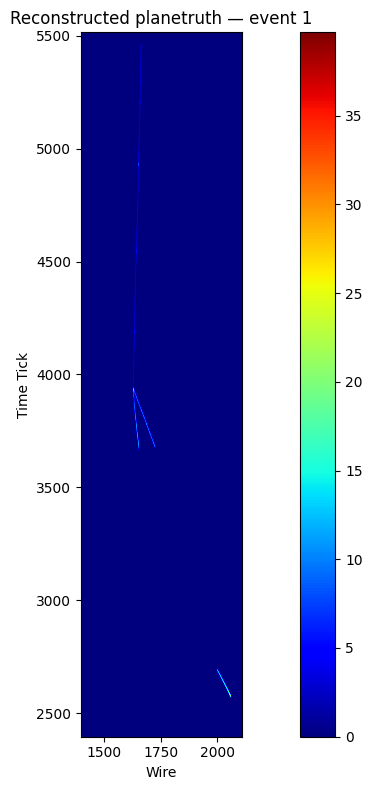

In [88]:
# Read the saved sparse HDF5 and plot a reconstructed event (similar to previous imshow)
import h5py
import numpy as np
import matplotlib.pyplot as plt

h5path = 'planetruth_sparse.h5'
with h5py.File(h5path, 'r') as hf:
    coords = hf['coords'][:]
    values = hf['values'][:]
    offsets = hf['offsets'][:]
    bboxes = hf['bboxes'][:]
    shape = tuple(hf.attrs['planetruth_shape'])

# pick first event that has non-zero entries
event_idx = None
for i in range(len(offsets)-1):
    if offsets[i+1] > offsets[i]:
        event_idx = i
        break
if event_idx is None:
    raise RuntimeError('No non-empty events found in ' + h5path)

event_idx = 1  # or set to any valid event index

s = offsets[event_idx]; e = offsets[event_idx+1]
coords_e = coords[s:e].astype(int)
vals_e = values[s:e]
A = np.zeros(shape, dtype=vals_e.dtype)
min_w, max_w, min_t, max_t = bboxes[event_idx]
# coords were saved relative to bbox origin (w0,t0); add offsets to place in full plane
if coords_e.shape[0] > 0:
    wires = coords_e[:,0] + int(min_w)
    times = coords_e[:,1] + int(min_t)
    A[wires, times] = vals_e

# use bbox padding for plotting



pad_w = 50
pad_t = 50
x0 = max(0, min_w - pad_w)
x1 = min(shape[0], max_w + pad_w)
y0 = max(0, min_t - pad_t)
y1 = min(shape[1], max_t + pad_t)

zmax = A.max() if A.size>0 else 1.0
fig, ax = plt.subplots(1,1, figsize=(12,8))
im = ax.imshow(A.T, vmin=0, vmax=zmax, origin='lower', cmap='jet')
ax.set_title(f'Reconstructed planetruth — event {event_idx}')
ax.set_xlabel('Wire')
ax.set_ylabel('Time Tick')
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()